In [ ]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

with open('/icd_results.json', 'r') as f:
    all_json = json.load(f)
with open('/icd_match_results.json', 'r') as f:
    match_json = json.load(f)

df_packets = pd.DataFrame(all_json['packets'])
df_attempts = pd.DataFrame(match_json['attempts'])

matched_nos = set(df_attempts[df_attempts['status'] == 'matched']['packet_no'])
df_packets['is_match'] = df_packets['packet_no'].isin(matched_nos)

interval_ms = 10000
df_packets['interval'] = (df_packets['icd_ms'] // interval_ms) * interval_ms

grouped = df_packets.groupby('interval').agg(
    total_packet=('packet_no', 'count'),
    matched_packet=('is_match', 'sum')
).reset_index()

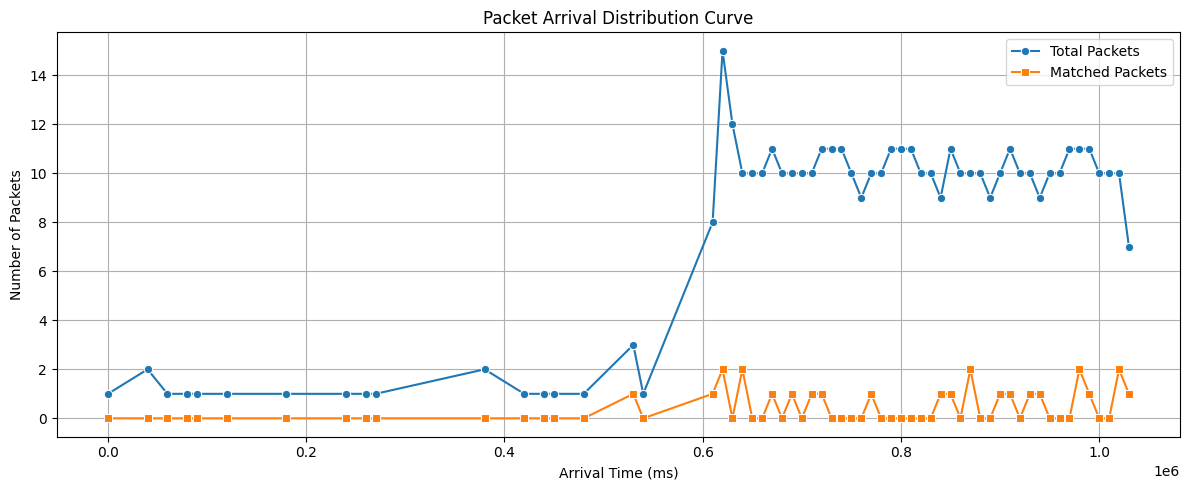

In [30]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=grouped, x='interval', y='total_packet', label='Total Packets', marker='o', color='#1f77b4')
sns.lineplot(data=grouped, x='interval', y='matched_packet', label='Matched Packets', marker='s', color='#ff7f0e')
plt.title('Packet Arrival Distribution Curve')
plt.xlabel('Arrival Time (ms)')
plt.ylabel('Number of Packets')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
n_bits = 4
total_possibilities = 2 ** n_bits
matching_outcomes = 1
probability = matching_outcomes / total_possibilities

print(f"Total probability {n_bits} bit: {total_possibilities} (0000 - 1111)")
print(f"{probability} / {probability * 100:.2f}%")

Total probability 4 bit: 16 (0000 - 1111)
0.0625 / 6.25%


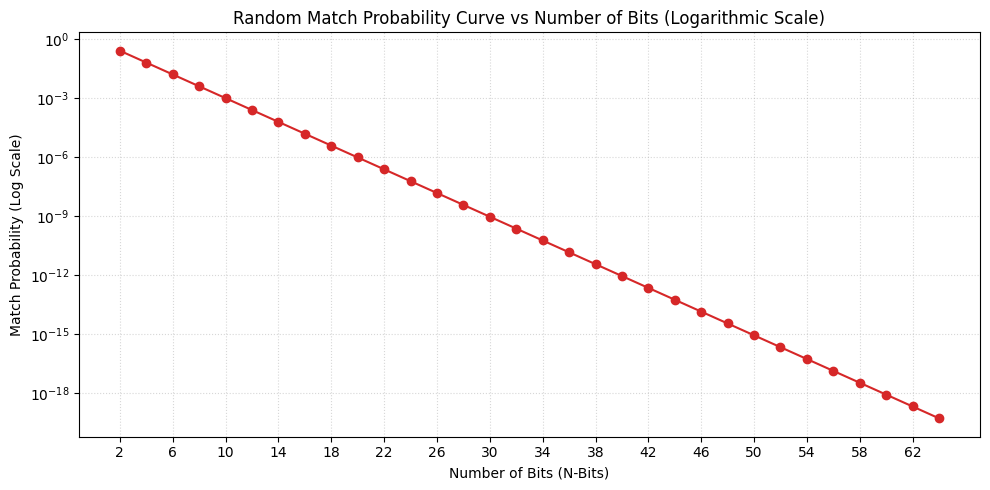

In [31]:
import numpy as np
import matplotlib.pyplot as plt

bit_sizes = list(range(2, 66, 2))
probabilities = [1 / (2 ** b) for b in bit_sizes]

plt.figure(figsize=(10, 5))
plt.plot(bit_sizes, probabilities, marker='o', linestyle='-', color='#d62728')
plt.yscale('log')
plt.title('Random Match Probability Curve vs Number of Bits (Logarithmic Scale)')
plt.xlabel('Number of Bits (N-Bits)')
plt.ylabel('Match Probability (Log Scale)')
plt.xticks(list(range(2, 66, 4)))
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

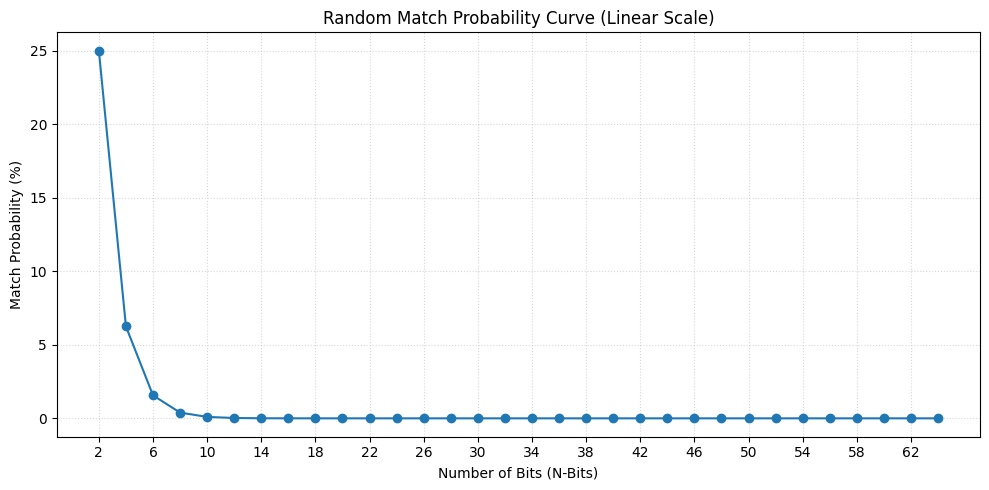

In [32]:
import numpy as np
import matplotlib.pyplot as plt

bit_sizes = list(range(2, 66, 2))
percentages = [(1 / (2 ** b)) * 100 for b in bit_sizes]

plt.figure(figsize=(10, 5))
plt.plot(bit_sizes, percentages, marker='o', linestyle='-', color='#1f77b4')
plt.title('Random Match Probability Curve (Linear Scale)')
plt.xlabel('Number of Bits (N-Bits)')
plt.ylabel('Match Probability (%)')
plt.xticks(list(range(2, 66, 4)))
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()